# Compare OSM and DC data

In [1]:
import requests
import geopandas as gpd
import pandas as pd
import numpy as np
import seaborn as sns
import osmnx as ox
import matplotlib.pyplot as plt
import shapely

## Data Acquisition

Get OSM data from: [https://overpass-turbo.eu/](https://overpass-turbo.eu/) with the following query:
```
/*
This has been generated by the overpass-turbo wizard.
The original search was:
"highway=* in Washington"
*/
[out:json][timeout:25];
// fetch area "Washington" to search in
{{geocodeArea:Washington}}->.searchArea;
// gather results
nwr["highway"](area.searchArea);
// print results
out geom;
```

DC data is acquired with the steps below.

In [2]:
# 2) Get Roadblock data from website
CRS = 'EPSG:4326'
def try_fetch_dc_roads():
    url = "https://opendata.arcgis.com/datasets/DCGIS::roadway-subblock.geojson"
    try:
        print('trying website')
        r = requests.get(url, timeout=60)
        r.raise_for_status()
        print(r)
        print(url)
        if r.ok:
            gj = r.json()
            roads = gpd.GeoDataFrame.from_features(gj["features"], crs=CRS)
            return roads
    except Exception as error:
        print('Error reading road data from dc gov website')

roads = try_fetch_dc_roads()
roads['index'] = roads.index
roads.to_file('Roadway_SubBlock_downloaded.geojson')
roads_csv = roads.drop(columns='geometry')
roads_csv.to_csv('Roadway_SubBlock_downloaded.csv')
roads

trying website
<Response [200]>
https://opendata.arcgis.com/datasets/DCGIS::roadway-subblock.geojson


,geometry,ROUTEID,FROMMEASURE,TOMEASURE,ROUTENAME,ROADTYPE,SUBBLOCKKEY,TOTALTRAVELLANES,TOTALPARKINGLANES,TOTALRAISEDBUFFERS,...,SMD_ID,ANC_ID,NETWORK_LOGICAL_END,AADT_COMBINATION,AADT_COMBINATION_YEAR,AADT_SINGLE_UNIT,AADT_SINGLE_UNIT_YEAR,OBJECTID,SHAPELEN,index
0,"LINESTRING Z (-77.01604 38.95522 0, -77.01605 ...",11000302,3914.391357,3945.683594,3RD ST NW,1,6e140e615a8aece6b4e60e98fd55e37f,3,1,0,...,4D02,4D,NaN,NaN,NaN,NaN,NaN,10048555,0,0
1,"LINESTRING Z (-77.01554 38.94482 0, -77.01555 ...",11000302,3026.942383,3088.800049,3RD ST NW,1,98bcf0baa7ae2b740bd92ae6d1f853aa,2,3,0,...,4C05,4C,NaN,NaN,NaN,NaN,NaN,10048556,0,1
2,"LINESTRING Z (-77.01571 38.94859 0, -77.01572 ...",11000302,3178.634521,3260.639648,3RD ST NW,1,024b301014c83ea186d1f2d64fee86b8,2,3,0,...,4D05,4D,NaN,NaN,NaN,NaN,NaN,10048557,0,2
3,"LINESTRING Z (-77.01594 38.95326 0, -77.01595 ...",11000302,3696.937988,3796.992432,3RD ST NW,1,abe913b5ebaa753da8452455edee1c12,2,3,0,...,4D07,4D,NaN,NaN,NaN,NaN,NaN,10048558,0,3
4,"LINESTRING Z (-77.01586 38.9137 0, -77.01582 3...",11000302,2079.489990,2111.326904,3RD ST NW,1,024154cc3185f8763181362cb4bc642f,3,1,0,...,5E03,5E,NaN,NaN,NaN,NaN,NaN,10048559,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34955,"LINESTRING Z (-77.05249 38.88856 0, -77.0531 3...",64097213,176.141006,773.181030,ARLINGTON MEMORIAL BRIDGE CONNECTOR SW,6,2a3d1883d5ea0f306abb25302f9a818c,0,0,0,...,2A04,2A,NaN,NaN,NaN,NaN,NaN,10084598,0,34955
34956,"LINESTRING Z (-77.05879 38.88628 0, -77.05887 ...",64097213,778.463989,785.866028,ARLINGTON MEMORIAL BRIDGE CONNECTOR SW,6,bba559445cd6be3fa165c65f7ad5c493,0,0,0,...,2A04,2A,NaN,NaN,NaN,NaN,NaN,10084599,0,34956
34957,"LINESTRING Z (-77.06126 38.88538 0, -77.06179 ...",64097213,1085.380005,1136.157959,ARLINGTON MEMORIAL BRIDGE CONNECTOR SW,6,8770b43dca22b76fd2a59417e3b2ddcf,0,0,0,...,2A04,2A,NaN,NaN,NaN,NaN,NaN,10084600,0,34957
34958,"LINESTRING Z (-77.05887 38.88625 0, -77.05903 ...",64097213,785.866028,910.003601,ARLINGTON MEMORIAL BRIDGE CONNECTOR SW,6,f98444efd53f8095cac7e078a0d27a92,0,0,0,...,2A04,2A,NaN,NaN,NaN,NaN,NaN,10084601,0,34958


In [3]:
roads = gpd.read_file('Roadway_SubBlock_downloaded.geojson')

<Axes: >

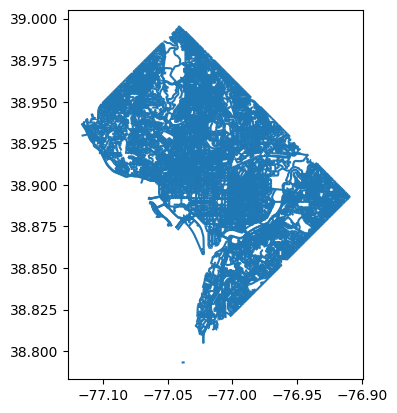

In [4]:
roads.plot()

### clip to DC area

DC geometry is from OSM, clip both datasets to this

In [5]:
aoi_gdf = ox.geocode_to_gdf("Washington, District of Columbia, USA").to_crs("EPSG:4326")
aoi = aoi_gdf.geometry.iloc[0]
aoi_gdf.explore()

In [7]:
osm = gpd.read_file('OSM_dc.geojson')
print('all shapes: '+str(len(osm)))
osm = osm[osm.geometry.geom_type.isin(['LineString', 'MultiLineString'])]
print('all shapes: '+str(len(osm)))
osm_csv = osm.drop(columns='geometry')
osm_csv.to_csv('osm_downloaded.csv')
osm

all shapes: 125279
all shapes: 88618


,id,@id,FIXME:hgv,FIXME:lanes,HFCS,NHS,abandoned:railway,access,access:conditional,access:lanes:backward,...,website,wheelchair,width,wikidata,wikimedia_commons,wikipedia,zip_left,zip_right,zoo,geometry
342,way/4681186,way/4681186,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (-77.10826 38.93574, -77.10826 38.9..."
343,way/4725152,way/4725152,NaN,NaN,Collector,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (-76.93866 38.88917, -76.93838 38.8..."
344,way/5967442,way/5967442,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (-77.10231 38.95533, -77.10227 38.9..."
345,way/5968135,way/5968135,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (-77.07191 38.97399, -77.07156 38.9..."
346,way/5969679,way/5969679,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (-77.07585 38.96851, -77.07582 38.9..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88955,way/1503393861,way/1503393861,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (-77.04701 38.93422, -77.04703 38.9..."
88956,way/1503393862,way/1503393862,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (-77.04724 38.93462, -77.0474 38.93..."
88957,way/1503394827,way/1503394827,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (-77.03637 38.94789, -77.0363 38.94..."
88958,way/1503394828,way/1503394828,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (-77.03597 38.94827, -77.03596 38.9..."


<Axes: >

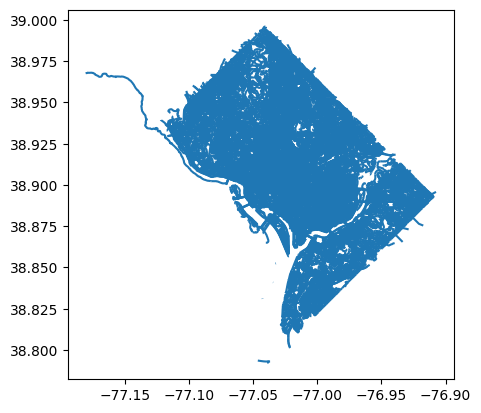

In [8]:
osm.plot()

<Axes: >

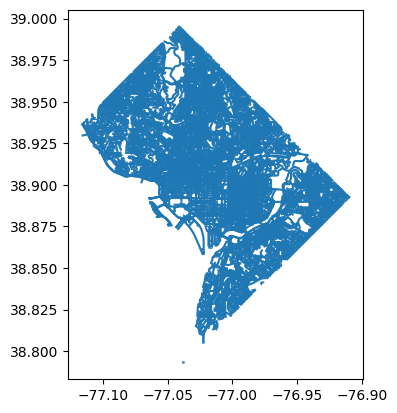

In [9]:
dc_clipped = gpd.clip(roads, aoi_gdf.dissolve())
dc_clipped.plot()

<Axes: >

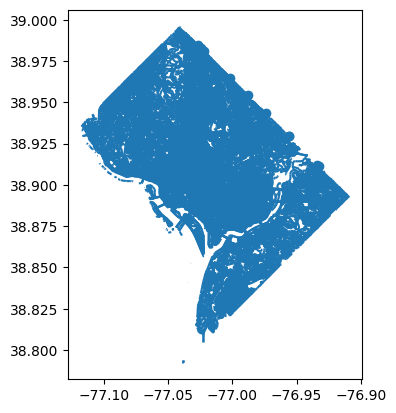

In [10]:
osm_clipped = gpd.clip(osm, aoi_gdf.dissolve())
osm_clipped.plot()

In [11]:
utm_crs = osm_clipped.estimate_utm_crs()
osm_clipped = osm_clipped.to_crs(utm_crs)
dc_clipped = dc_clipped.to_crs(utm_crs)

In [12]:
#compare lengths (raw), we will be narrowing down the lines later to just roads/trails of interest
osm_clipped['length'] = osm_clipped.length
dc_clipped['length'] = dc_clipped.length
print('length of osm data within dc: '+str(int(sum(osm_clipped['length'])/1000))+' km')
print('length of dc data within dc: '+str(int(sum(dc_clipped['length'])/1000))+ ' km')

length of osm data within dc: 6663 km
length of dc data within dc: 2960 km


The osm data is about twice as long. It might include sidewalks and whatnot so we will narrow down the datasets to just roads and trail later.

In [13]:
print('OSM columns ('+str(len(osm_clipped.columns))+')')
for c in osm_clipped.columns:
    print(c)

OSM columns (518)
id
@id
FIXME:hgv
FIXME:lanes
HFCS
NHS
abandoned:railway
access
access:conditional
access:lanes:backward
access_control
addr:city
addr:floor
addr:housenumber
addr:postcode
addr:state
addr:street
agricultural
alt_name
alt_name:etymology
alt_name:etymology:wikidata
alt_name:wikidata
amenity
area
area:highway
barrier
bench
bicycle
bicycle:lanes
bicycle_road
bin
brand
brand:wikidata
bridge
bridge:movable
bridge:name
bridge:name:etymology:wikidata
bridge:structure
bridleway
building:levels
bus
bus:lanes:backward
bus_bay
busway:both
busway:right
busway:right:conditional
button_operated
change:lanes
change:lanes:backward
change:lanes:forward
check_date
check_date:bench
check_date:crossing
check_date:cycleway
check_date:handrail
check_date:lit
check_date:ramp
check_date:shelter
check_date:smoothness
check_date:surface
check_date:tactile_paving
check_date:wheelchair
colour
commuter_bus
condition
construction
conveying
covered
created_by
crossing
crossing:continuous
crossing:isl

In [14]:
print('DC columns ('+str(len(dc_clipped.columns))+')')
for c in dc_clipped.columns:
    print(c)

DC columns (93)
ROUTEID
FROMMEASURE
TOMEASURE
ROUTENAME
ROADTYPE
SUBBLOCKKEY
TOTALTRAVELLANES
TOTALPARKINGLANES
TOTALRAISEDBUFFERS
TOTALTRAVELLANEWIDTH
TOTALCROSSSECTIONWIDTH
TOTALPARKINGLANEWIDTH
TOTALTRAVELLANESINBOUND
TOTALTRAVELLANESOUTBOUND
TOTALTRAVELLANESBIDIRECTIONAL
TOTALTRAVELLANESREVERSIBLE
SUMMARYDIRECTION
BIKELANE_PARKINGLANE_ADJACENT
BIKELANE_THROUGHLANE_ADJACENT
BIKELANE_POCKETLANE_ADJACENT
BIKELANE_CONTRAFLOW
BIKELANE_CONVENTIONAL
BIKELANE_DUAL_PROTECTED
BIKELANE_DUAL_BUFFERED
BIKELANE_PROTECTED
BIKELANE_BUFFERED
DOUBLEYELLOW_LINE
SECTIONFLAGS
LOC_ERROR
MIDMEASURE
AADT
FHWAFUNCTIONALCLASS
HPMSID
HPMSSECTIONTYPE
ID
IRI
IRI_DATE
NHSCODE
OWNERSHIP
PCI_CONDCATEGORY
PCI_LASTINSPECTED
PCI_SCORE
SIDEWALK_IB_PAVTYPE
SIDEWALK_IB_WIDTH
SIDEWALK_OB_PAVTYPE
SIDEWALK_OB_WIDTH
SPEEDLIMITS_IB
SPEEDLIMITS_IB_ALT
SPEEDLIMITS_OB
SPEEDLIMITS_OB_ALT
SUBBLOCKID
BLOCKID
BLOCKKEY
DCFUNCTIONALCLASS
NHSTYPE
QUADRANT
STREETNAME
STREETTYPE
SNOWROUTE_DPW
SNOWZONE_DPW
SNOWROUTE
SNOWSECTION
SNOWZONE

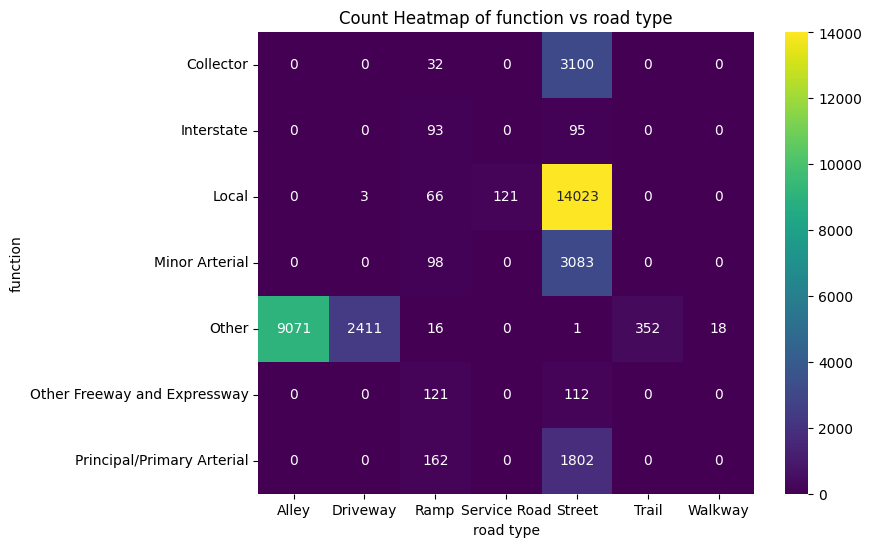

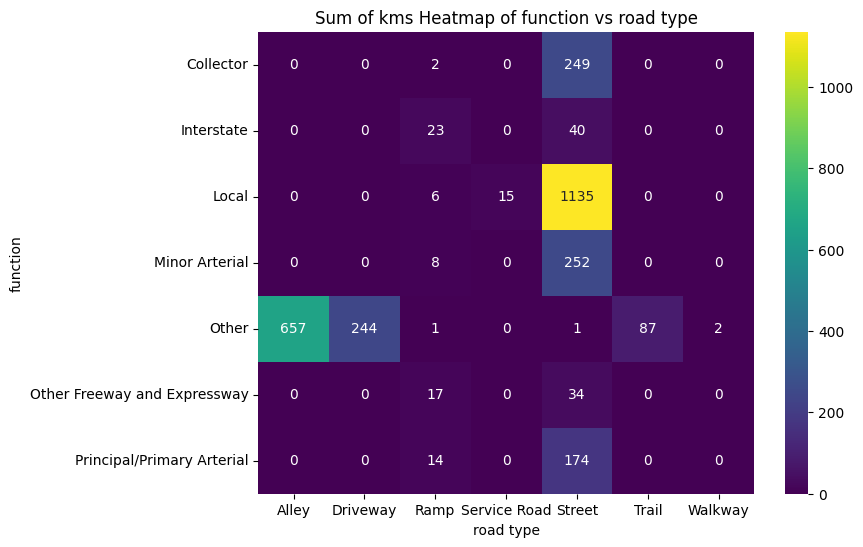

In [15]:
# get road functions for DC

#replace function number with name
function_dict = {11: 'Interstate', 12: 'Other Freeway and Expressway', 14:  'Principal/Primary Arterial', 16:  'Minor Arterial', 17:  'Collector', 19:'Local'}
def name_function(x):
    if x in function_dict.keys():
        return function_dict[x]
    else:
        return 'Other'

roadtype_dict = {'1': "Street", '2':  "Service Road", '3':  "Ramp", '4':  "Alley", '5':  "Driveway", '6':  "Trail", '7':  "Walkway", '8':  "Streetcar"}
def name_roadtype(x):
    if x in roadtype_dict.keys():
        return roadtype_dict[x]
    else:
        return 'Other'

dc_clipped['function_name'] = dc_clipped['DCFUNCTIONALCLASS'].apply(lambda x: name_function(x))
dc_clipped['roadtype_name'] = dc_clipped['ROADTYPE'].apply(lambda x: name_roadtype(x))


heatmap_data = pd.crosstab(dc_clipped['function_name'], dc_clipped['roadtype_name'])
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='viridis')
plt.xlabel('road type')
plt.ylabel('function')
plt.title('Count Heatmap of function vs road type')
plt.show()

heatmap_data = (
    dc_clipped.groupby(['function_name', 'roadtype_name'])['length']
      .sum()
      .unstack(fill_value=0)
)
heatmap_data = heatmap_data / 1000
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, fmt ='.0f', cmap='viridis')
plt.xlabel('road type')
plt.ylabel('function')
plt.title('Sum of kms Heatmap of function vs road type')
plt.show()


In [16]:
#get rid of walkway and get road type/function name column
dc_clipped = dc_clipped[dc_clipped['function_name'] != 'Walkway']
dc_clipped.loc[dc_clipped['roadtype_name'] == 'Other', 'roadtype_name'] = 'Miscellaneous'
dc_clipped['roadtype_function'] = dc_clipped['function_name'].str[:56]+', '+dc_clipped['roadtype_name']
dc_clipped['roadtype_function']

34818       Other, Trail
21385      Local, Street
34322    Other, Driveway
34320    Other, Driveway
34321    Other, Driveway
              ...       
8640       Local, Street
4519       Local, Street
10029      Local, Street
9393       Local, Street
4516       Local, Street
Name: roadtype_function, Length: 34780, dtype: str

In [17]:
print('number of segments:')
print(osm_clipped['highway'].value_counts())
gb = osm_clipped.groupby(['highway'])['length'].sum().sort_values(ascending=False)
print('length (kms):')
print(gb/1000)

number of segments:
highway
footway           51440
service           17434
residential        5412
primary            2907
cycleway           2171
secondary          2100
tertiary           1958
steps              1618
path                815
unclassified        489
trunk               477
motorway_link       431
motorway            427
primary_link        309
proposed            129
pedestrian          108
secondary_link       71
trunk_link           64
tertiary_link        54
living_street        47
bridleway            46
track                41
corridor             35
construction         33
no                    1
Name: count, dtype: int64
length (kms):
highway
footway           2807.499252
service           1442.533586
residential       1044.646849
tertiary           279.862859
primary            255.151788
secondary          205.141579
cycleway           190.249974
path                93.635047
motorway            74.158353
unclassified        66.207185
motorway_link       52.3

In [18]:
types = osm_clipped.groupby(['highway'])['length'].sum()
small_remove = types[types<5]
osm_remove = ['footway', 'proposed', 'steps', 'construction', 'platform', 'elevator', 'no', 'pedestrian']+list(small_remove.index)
osm_clipped = osm_clipped[~osm_clipped['highway'].isin(osm_remove)]
osm_clipped

,id,@id,FIXME:hgv,FIXME:lanes,HFCS,NHS,abandoned:railway,access,access:conditional,access:lanes:backward,...,wheelchair,width,wikidata,wikimedia_commons,wikipedia,zip_left,zip_right,zoo,geometry,length
24826,way/566907725,way/566907725,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (325126.157 4298086.093, 325132.705...",6.936401
821,way/6053277,way/6053277,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (325087.073 4298179.082, 325105.332...",184.729804
24825,way/566907724,way/566907724,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (325132.705 4298088.381, 325200.518...",73.526669
24829,way/566907731,way/566907731,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (325129.665 4298107.335, 325193.77 ...",133.660265
24823,way/566907721,way/566907721,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (325188.67 4298151.97, 325120.339 4...",92.974191
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10269,way/253129879,way/253129879,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTILINESTRING ((323677.779 4317345.724, 3236...",578.487664
10267,way/253129877,way/253129877,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (323814.948 4317503.223, 323819.265...",135.747173
893,way/6053597,way/6053597,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (323880.325 4317629.681, 323870.499...",336.155869
1639,way/6056192,way/6056192,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (323832.346 4317603.882, 323824.768...",201.045914


In [19]:
print('number of segments:')
print(osm_clipped['highway'].value_counts())
gb = osm_clipped.groupby(['highway'])['length'].sum().sort_values(ascending=False)
print('length (kms):')
print(gb/1000)

number of segments:
highway
service           17434
residential        5412
primary            2907
cycleway           2171
secondary          2100
tertiary           1958
path                815
unclassified        489
trunk               477
motorway_link       431
motorway            427
primary_link        309
secondary_link       71
trunk_link           64
tertiary_link        54
living_street        47
bridleway            46
track                41
corridor             35
Name: count, dtype: int64
length (kms):
highway
service           1442.533586
residential       1044.646849
tertiary           279.862859
primary            255.151788
secondary          205.141579
cycleway           190.249974
path                93.635047
motorway            74.158353
unclassified        66.207185
motorway_link       52.398693
trunk               49.721398
primary_link        21.881506
bridleway           15.660075
track                5.356568
living_street        3.774304
secondary_link    

In [20]:
print('length of osm data within dc: '+str(int(sum(osm_clipped['length'])/1000))+' km')
print('length of dc data within dc: '+str(int(sum(dc_clipped['length'])/1000))+ ' km')

length of osm data within dc: 3812 km
length of dc data within dc: 2960 km


### Column summary/comparison

In [34]:
osm_summary = osm_clipped.describe(include='all')

In [35]:
osm_summary = osm_summary.transpose().sort_values('count', ascending = False) #.to_csv('osm_summary.csv')

In [36]:
for i in range(10):
    osm_summary['top '+str(i)] = ''
    osm_summary['top '+str(i)+' count'] = np.nan
for it, row in osm_summary.iterrows():
    curr_value_counts = osm_clipped[it].value_counts().sort_values(ascending = False)
    for i in range(min(len(osm_clipped[it].value_counts()), 10)):
        osm_summary.loc[it, 'top '+str(i)] = str(curr_value_counts.index[i])
        osm_summary.loc[it, 'top '+str(i)+ ' count'] = curr_value_counts.values[i]
osm_summary.to_csv('osm_summary.csv')
osm_summary

,count,unique,top,freq,mean,min,25%,50%,75%,max,...,top 5,top 5 count,top 6,top 6 count,top 7,top 7 count,top 8,top 8 count,top 9,top 9 count
id,35288,35288,way/566907725,1,NaN,NaN,NaN,NaN,NaN,NaN,...,way/566907723,1.0,way/765668237,1.0,way/765668240,1.0,way/1238291478,1.0,way/765668236,1.0
highway,35288,19,service,17434,NaN,NaN,NaN,NaN,NaN,NaN,...,tertiary,1958.0,path,815.0,unclassified,489.0,trunk,477.0,motorway_link,431.0
geometry,35288,35288,LINESTRING (325126.15664394334 4298086.0932003...,1,NaN,NaN,NaN,NaN,NaN,NaN,...,LINESTRING (325105.3315523845 4298135.65255053...,1.0,LINESTRING (325123.55754363205 4298216.0629892...,1.0,LINESTRING (325123.55754363205 4298216.0629892...,1.0,LINESTRING (325146.4474857863 4298219.98876717...,1.0,LINESTRING (325161.50728385017 4298245.4505682...,1.0
@id,35288,35288,way/566907725,1,NaN,NaN,NaN,NaN,NaN,NaN,...,way/566907723,1.0,way/765668237,1.0,way/765668240,1.0,way/1238291478,1.0,way/765668236,1.0
length,35288.0,NaN,NaN,NaN,108.037398,0.0,29.610121,62.048893,127.877024,4066.344394,...,107.27838745276011,1.0,35.82400394315512,1.0,23.509915595640045,1.0,23.37713879943466,1.0,50.12383196995145,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
dcgis:shape_len,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,,NaN,,NaN,,NaN,,NaN,,NaN
operator:wikidata,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,,NaN,,NaN,,NaN,,NaN,,NaN
operator:wikipedia,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,,NaN,,NaN,,NaN,,NaN,,NaN
ownership,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,,NaN,,NaN,,NaN,,NaN,,NaN


In [37]:
dc_summary = dc_clipped.describe(include='all')
dc_summary = dc_summary.transpose().sort_values('count', ascending = False)
for i in range(10):
    dc_summary['top '+str(i)] = ''
    dc_summary['top '+str(i)+' count'] = np.nan
for it, row in dc_summary.iterrows():
    curr_value_counts = dc_clipped[it].value_counts().sort_values(ascending = False)
    for i in range(min(len(dc_clipped[it].value_counts()), 10)):
        dc_summary.loc[it, 'top '+str(i)] = str(curr_value_counts.index[i])
        dc_summary.loc[it, 'top '+str(i)+ ' count'] = curr_value_counts.values[i]
dc_summary.to_csv('dc_summary.csv')
dc_summary

,count,unique,top,freq,mean,min,25%,50%,75%,max,...,top 5,top 5 count,top 6,top 6 count,top 7,top 7 count,top 8,top 8 count,top 9,top 9 count
ROUTEID,34780,13939,11001402,146,NaN,NaN,NaN,NaN,NaN,NaN,...,11059602,106.0,11000802,106.0,11000702,103.0,11001702,102.0,11040042,98.0
TOSTREET,34780,1,Block Only,34780,NaN,NaN,NaN,NaN,NaN,NaN,...,,NaN,,NaN,,NaN,,NaN,,NaN
ID,34780,34780,8456eaa9-951b-4037-b2aa-b0bb18090c45,1,NaN,NaN,NaN,NaN,NaN,NaN,...,8276078d-eb11-47fa-a2bd-be9c081ec657,1.0,b7e54388-48c9-4370-bcf3-4046abdd5a30,1.0,084af0ec-7210-43dc-9c36-deb73e85bd09,1.0,989ad9a5-07f6-4e6a-a706-85fab5d0fcbe,1.0,169f111a-2a52-4ae1-a3a6-769e74fd6343,1.0
FROMMEASURE,34780.0,NaN,NaN,NaN,846.830258,0.0,0.0,190.28965,1161.387451,10703.892578,...,0.0005,152.0,94.15709686,2.0,185.48970032,2.0,14.85999966,2.0,141.99949646,2.0
SUBBLOCKID,34780,34780,64010532-14027992_58023712_64010532-00001,1,NaN,NaN,NaN,NaN,NaN,NaN,...,14027992-14027992_14083232-14027992_58023712_6...,1.0,14083232-14083232_58023722_58024412-14027992_1...,1.0,14083232-14083232_58003392-14083232_58023722_5...,1.0,14027992-14027992_58024332-14027992_14083232,1.0,14020452-14020452_14033592-14020442_14020452,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LEFTTURN_CURBLANE_EXCL,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,,NaN,,NaN,,NaN,,NaN,,NaN
SPEEDLIMITS_IB_ALT,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,,NaN,,NaN,,NaN,,NaN,,NaN
SPEEDLIMITS_IB,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,,NaN,,NaN,,NaN,,NaN,,NaN
MIDMEASURE,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,,NaN,,NaN,,NaN,,NaN,,NaN


In [38]:
osm_clipped.to_file('osm_clipped.geojson')
dc_clipped.to_file('dc_clipped.geojson')